# 🧠 Notebook 04: Deep Learning Model (Basic LSTM)

**Project Title:** Email Intent Classification with Attention-Based Sequence Models and Priority Prediction  
**Phase Covered:** Phase 5 (Basic LSTM Model Development)

---

### 🎯 Objectives:
1. Tokenize cleaned email texts using Keras `Tokenizer` (`max_words=5000`).
2. Pad sequences to fixed max length (`max_len=30`).
3. Encode intent labels into integers using `LabelEncoder`.
4. Build sequence model: Embedding -> LSTM(64) -> Dropout -> Dense -> Softmax.
5. Train model with Early Stopping on validation loss.
6. Plot training history (accuracy & loss curves) saved to `results/figures/lstm_training_history.png`.
7. Evaluate test set performance and generate confusion matrix (`results/figures/lstm_confusion_matrix.png`).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")


## 1. Load Data & Tokenize Sequences

In [2]:
train_df = pd.read_csv("../data/processed/train_emails.csv")
val_df = pd.read_csv("../data/processed/val_emails.csv")
test_df = pd.read_csv("../data/processed/test_emails.csv")

# Encode Labels
label_encoder = joblib.load("../models/label_encoder.pkl")
y_train = label_encoder.transform(train_df['intent'])
y_val = label_encoder.transform(val_df['intent'])
y_test = label_encoder.transform(test_df['intent'])

# Load Tokenizer & Sequence Padding
tokenizer = joblib.load("../models/tokenizer.pkl")
max_len = 30

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_email_text']), maxlen=max_len, padding='post', truncating='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_email_text']), maxlen=max_len, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_email_text']), maxlen=max_len, padding='post', truncating='post')

print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_test_seq shape:  {X_test_seq.shape}")


X_train_seq shape: (1773, 30)
X_test_seq shape:  (380, 30)


## 2. Build & Compile Basic LSTM Model

In [3]:
num_classes = len(label_encoder.classes_)
max_words = 5000
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


C:\Users\Vivek wadher\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. Train LSTM Model

In [4]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=25,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

model.save("../models/lstm_model.keras")


Epoch 1/25


 1/56 ━━━━━━━━━━━━━━━━━━━━ 1:18 1s/step - accuracy: 0.0625 - loss: 2.8261

 7/56 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0494 - loss: 2.8311 

13/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0477 - loss: 2.8323

20/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0544 - loss: 2.8324

...

29/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8202 - loss: 0.4652

36/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8205 - loss: 0.4693

44/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8201 - loss: 0.4705

52/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8200 - loss: 0.4701

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8203 - loss: 0.4698 - val_accuracy: 0.6000 - val_loss: 1.9532


## 4. Plot Training History

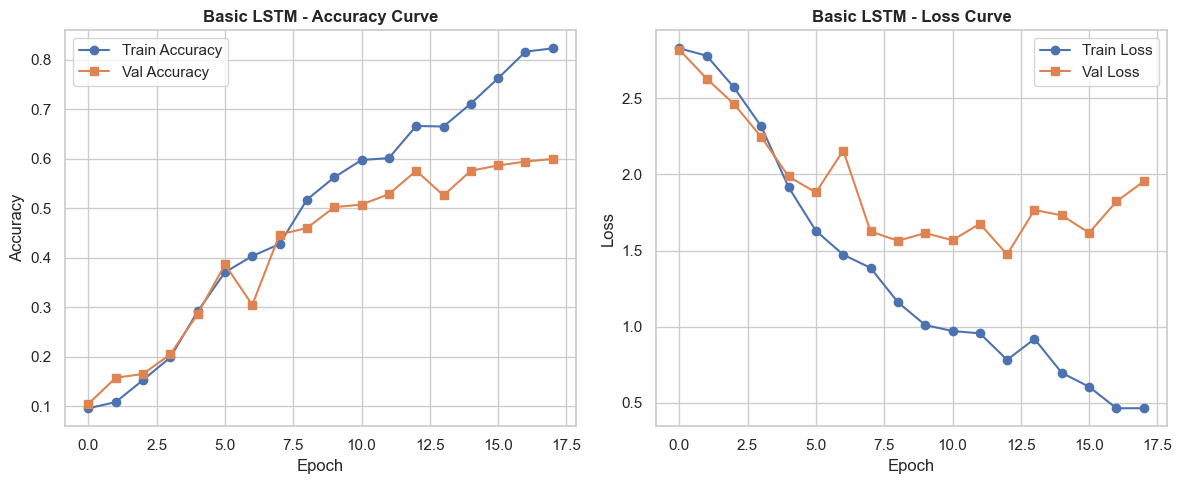

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Basic LSTM - Accuracy Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Basic LSTM - Loss Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("../results/figures/lstm_training_history.png", dpi=300)
plt.show()


## 5. Evaluate on Test Set & Confusion Matrix

 1/12 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


Accuracy:           0.5579
Weighted Precision: 0.5884
Weighted Recall:    0.5579
Weighted F1-Score:  0.5473


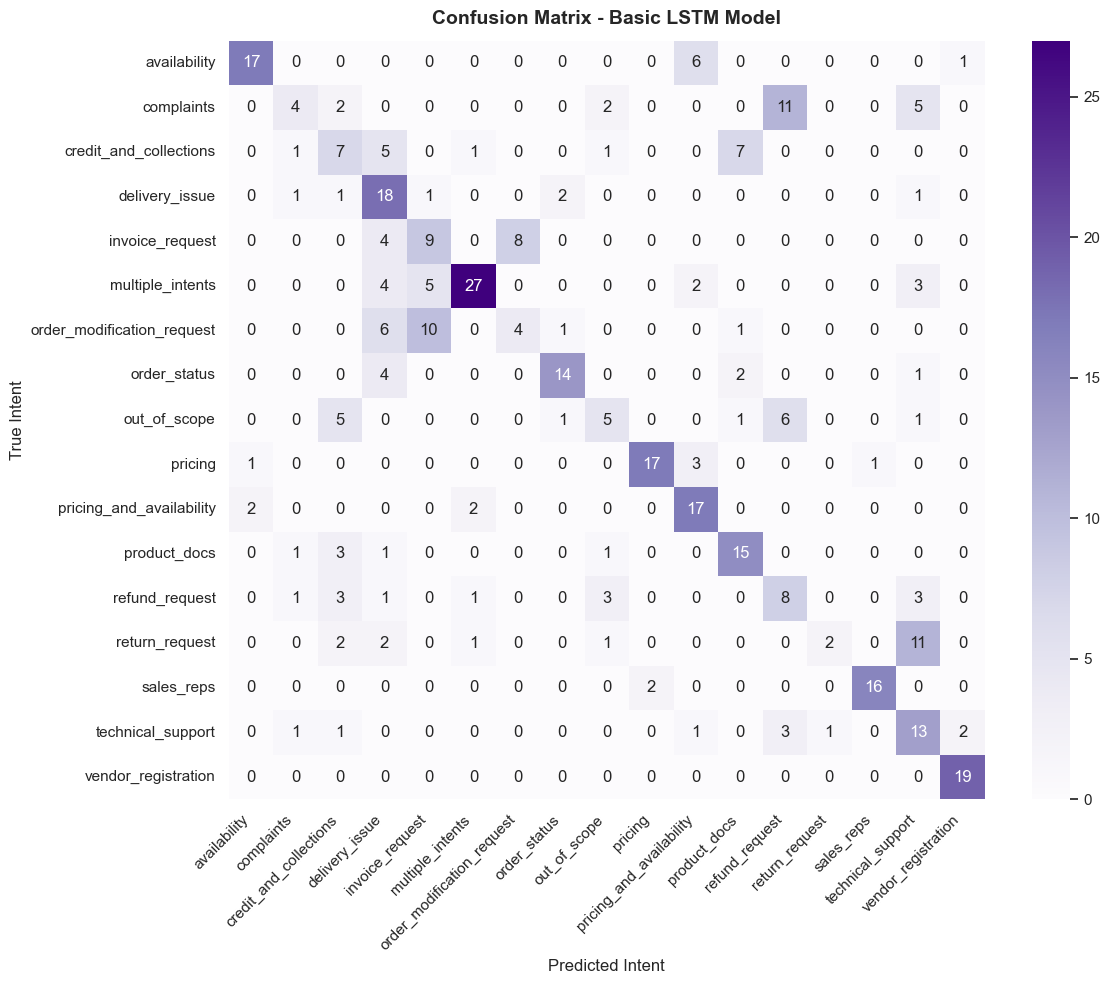

LSTM metrics and confusion matrix saved.


In [6]:
y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')

print(f"Accuracy:           {acc:.4f}")
print(f"Weighted Precision: {prec_w:.4f}")
print(f"Weighted Recall:    {rec_w:.4f}")
print(f"Weighted F1-Score:  {f1_w:.4f}")

labels = list(label_encoder.classes_)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Basic LSTM Model", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/figures/lstm_confusion_matrix.png", dpi=300)
plt.show()

metrics_df = pd.DataFrame([{
    'Model': 'LSTM',
    'Architecture': 'Embedding + LSTM + Dense',
    'Accuracy': acc,
    'Precision': prec_w,
    'Recall': rec_w,
    'F1_Score': f1_w,
    'Macro_Precision': prec_m,
    'Macro_Recall': rec_m,
    'Macro_F1_Score': f1_m
}])
metrics_df.to_csv("../results/metrics/lstm_metrics.csv", index=False)
print("LSTM metrics and confusion matrix saved.")
